# TRI-MODEL WITH SHARED TAK1

In [47]:
# Would display a schematic of the BCR + TLR + NF-κB model (with A20 feedback).
# Commented out because "triModelA20Diagram.png" is not included in this repo.
# display("image/png", read("triModelA20Diagram.png"))

In [48]:
###########################################################################
### File locations  ######################################################
###########################################################################
### set up where CSV2Julia is
# Path to the Python parser that turns the reaction/parameter/rate-law CSVs into Julia ODE code.
# Used later by generateModel.jl (it builds the `python3 $locationOfCSV2Julia ...` command).
locationOfCSV2Julia="csv2Julia/csv2model-multiscale.py"
#we use the same initial conditions at the PNAS paper 2019 Mitchell Roy et al.
# Path to an initial-conditions CSV. NOT used anywhere in this notebook, and the
# initialConditions/ folder does not exist in this repo (initial conditions are set in runSimulation.jl instead).
fullModelInitFile="initialConditions/fullModelInits.csv"
# Folder holding one sub-folder per module (BCR/, TLR/, NFkB/, linking/), each with
# reactions.csv, parameters.csv and rateLaws.csv. Read as a global inside combineModels.jl.
moduleDefinitionFilesFolder="moduleDefinitionFiles/"
# Intended location of fixSpecies.jl ("Spexies" is a typo in the original). NOT used; the folder
# does not exist and fixSpecies.jl actually sits in the repo root.
locationOfFixSpexies="utilityFunctions/"

"utilityFunctions/"

In [49]:
#packages we need
using DifferentialEquations   # ODE/DDE solvers: ODEProblem, DDEProblem, ODEFunction, DDEFunction, solve, Rodas4
using DelayDiffEq
using Plots                   # plotting: plot, plot!, palette, gr(), grid layouts
using Pkg                     # Julia package manager (only needed for the commented Pkg.add line below)
# Pkg.add(Pkg.PackageSpec(;name="Parsers", version="2.2.4"))   # old workaround pinning Parsers for CSV compatibility
using CSV                     # reading/writing the model CSVs and the simulation output CSVs
using DataFrames              # DataFrame tables (combineModels, parametersDF, saved solutions)
using JLD2                    # binary .jld2 save/load (only referenced in a commented-out line in runSimulation.jl)
using FileIO                  # generic save/load interface used with JLD2
using StatsPlots              # statistical plot recipes on top of Plots
using Plots.PlotMeasures      # units like mm/px for plot margins
using Distributions           # Normal, LogNormal, Truncated: used for cell-to-cell variability
# Global switch read by combineModels.jl and runSimulation.jl:
# true  -> use reactions_withDelay.csv for NFkB + linking (transcriptional delays) and solve as delay equations (DDEs)
# false -> use reactions.csv and solve as ordinary ODEs
delay=true

true

In [50]:
# Load the combineModels(...) function definition from combineModels.jl
include("combineModels.jl")
# Merge the linking module with the BCR, TLR and NFkB modules into one model.
# - Reactions in a module that also appear in linking/ are dropped (linking wins).
# - Every parameter name gets a module suffix, e.g. "k3_signal" -> "k3_signal-BCR".
# - Writes combinedModelDefinitionFiles/{reactions,parameters,rateLaws}.csv
# combinedModelLocation = "combinedModelDefinitionFiles/" (the returned folder path), used by generateModel.jl
combinedModelLocation=combineModels(["BCR","TLR","NFkB"])

adding BCR module
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1 -> TAK1p as it is included in linking file
removing: TAK1p -> TAK1 as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
removing: TAK1C -> TAK1pC as it is included in linking file
adding module BCR to combined reaction array
finished BCR

adding TLR module
removing: TAK1 -> T

"combinedModelDefinitionFiles/"

In [51]:
# Runs generateModel.jl as a script (not a function). It:
# 1. Reads combinedModelLocation*"parameters.csv" into the global `parametersDF`
#    (columns: parameter, value, distribute). runSimulation uses its 3rd column (distribute == 1 -> vary per cell).
# 2. Calls `python3 csv2Julia/csv2model-multiscale.py <reactions> <parameters> <rateLaws> odeModel.jl param`,
#    which (re)writes odeModel.jl, scanIncludes.jl (paramVals, parameterNameList) and variableNames.jl (syms).
# 3. Includes odeModel.jl and moves it into distributedModelFiles/.
# Note: on Windows the command may need to be `python` or `py` instead of `python3`.
include("generateModel.jl")

param
Running CSV2JuliaDiffEq with parameters dynamically determined by a variable, re-run with the 5th argument set to 'scan' or 'inline'
Opening combinedModelDefinitionFiles/rateLaws.csv as rate law file
Opening combinedModelDefinitionFiles/parameters.csv as parameters file
Opening combinedModelDefinitionFiles/reactions.csv as reactions file


c:\Users\Oliver Fields\Desktop\BIE-Parser-Schema\csv2Julia\csv2model-multiscale.py:90: SyntaxWarning: invalid escape sequence '\['
  splitLaw=re.split('(\[[sS]\d{0,10}\])',thisLaw)
c:\Users\Oliver Fields\Desktop\BIE-Parser-Schema\csv2Julia\csv2model-multiscale.py:95: SyntaxWarning: invalid escape sequence '\d'
  if(part and part.startswith('[') and re.search('([sS]\d{0,10})',part)):
c:\Users\Oliver Fields\Desktop\BIE-Parser-Schema\csv2Julia\csv2model-multiscale.py:107: SyntaxWarning: invalid escape sequence '\['
  splitLaw=re.split('(\[[pP]\d{0,10}\])',thisLaw)
c:\Users\Oliver Fields\Desktop\BIE-Parser-Schema\csv2Julia\csv2model-multiscale.py:111: SyntaxWarning: invalid escape sequence '\d'
  if(part and part.startswith('[') and re.search('([pP]\d{0,10})',part)):
c:\Users\Oliver Fields\Desktop\BIE-Parser-Schema\csv2Julia\csv2model-multiscale.py:121: SyntaxWarning: invalid escape sequence '\['
  splitLaw=re.split('(\[[mM][Oo][Dd]\d{0,10}\])',thisLaw)
c:\Users\Oliver Fields\Desktop\BIE-P

Model generated for all conditions


In [52]:
# Load the stimulus functions of time t (minutes). defineInputs.jl defines, among others:
#   bcrSignalSS     = inputFuncSS      -> 0      (no tonic BCR signal)
#   bcrSignalSSHigh = inputFuncSSHigh  -> 0.005  (high tonic BCR signal)
#   tlrSignalSS     = inputFuncSS      -> 0      (no CpG)
#   nikSignalSS     = NIKFuncSS        -> 1      (constant NIK degradation modifier)
#   tlrSignalSmooth = ultra_smooth_bump          (smooth CpG pulse; peak time/height per cell)
# and the globals T = 2880 (bump time scale, min) and g(s) (bump shape) used inside runSimulation.
include("defineInputs.jl")

# Reminder list of the input aliases available from defineInputs.jl:
#bcrSignalSS
#bcrSignalSSHigh
#tlrSignalSS
#bcrSignalTC
#tlrSignalTC
#nikSignalSS
#nikSignalTC

t=0   # leftover global time variable; not used by the simulation
# Defines odeModel(dy,y,h,p,t): the generated DDE right-hand side (130 species, 480 parameters)
include("distributedModelFiles/odeModel.jl")
# Defines syms: vector of the 130 species names, in the same order as the state vector y
include("variableNames.jl")
# Defines paramVals (default values of all 480 parameters; some are functions of t)
# and parameterNameList (their names, e.g. "k1_CpGadding-TLR"), in matching order
include("scanIncludes.jl")
# const CBSWITCH_IDX = findfirst(==("cbswitch"), syms)   # leftover from an earlier event-switch version
# Index of the "CpG in the medium" species within syms/y. Only used by a commented-out callback in runSimulation.jl.
const CpGIndex = findfirst(==("CpGmedia"),syms)

# Defines runSimulation(...) (the steady-state + time-course solver loop)
include("runSimulation.jl")
# Defines plotAllSpecies(...) (older plotting function; not used below, plotAllSpeciesNew is used instead)
include("plotAllSpecies.jl")
# Colour palette: one colour per condition in the plots
colorArray=palette(:seaborn_colorblind)

first_cell=1      # index of the first virtual cell to simulate
last_cell=15      # index of the last virtual cell (15 cells in total)
preCV=0.11        # coefficient of variation (11%) used in runSimulation to randomise "distribute" parameters per cell
maxTimeTC=24*60   # length of the stimulated time course: 1440 min = 24 h (read as a global in runSimulation / plotting)
maxTimeSS=1000*60 # length of the unstimulated run used to reach steady state: 60,000 min = 1000 h

parameters can now be searched in parameterNameList by name.
example to modify k_binding 1.5 fold higher:
indexOfParam=findfirst(x->"k_binding"==x,parameterNameList)
paramVals[indexOfParam]=paramVals[indexOfParam]*1.5


60000

In [53]:
# Per-cell CpG/TLR stimulus: WHEN each cell's CpG input peaks and HOW HIGH it goes.
# These arrays are read (as globals) by ultra_smooth_bump in defineInputs.jl and by
# ultra_smooth_bump_local inside runSimulation.jl.

σ = 1.8        # log-normal shape parameter (note: overwrites the σ = 0.2 set in defineInputs.jl)
μ = σ^2        # log-normal location parameter (3.24) -> median peak time ≈ e^3.24 ≈ 25 min
# Distribution of peak times t* (minutes), truncated to 0–720 min (max 12 h)
timeOfStimDist=Truncated(LogNormal(μ, σ),0,720)
# 1×15 array holding each cell's peak time; filled in the loop below
TLRTimeArray=ones(1,last_cell)

# Distribution of pulse heights H: Normal(mean 1, SD 1), capped at 10.
heightDist=Truncated(Normal(1, 1),-Inf,10)
# 1×15 array holding each cell's pulse height; filled in the loop below
TLRHeightArray=ones(1,last_cell)

# Global "which cell am I" index read by ultra_smooth_bump (runSimulation uses its own local copy per cell)
globalCellIndex=1
for i in 1:last_cell                            # for each virtual cell
    y=rand(timeOfStimDist,1)                    # draw one peak time (returns a 1-element vector)
    TLRTimeArray[i]=y[1]                        # store it for cell i
    x=maximum([rand(heightDist,1)[1],0])        # draw one height and clamp negatives to 0 (~16% of cells get 0, i.e. no response)
    TLRHeightArray[i]=x[1]                      # store it for cell i
end

In [54]:
# Parallel arrays: entry k of each array describes condition k. All are passed to runSimulation.
conditions=[]       # condition names (also used in output file names)
paramsToChange=[]   # per condition: list of parameter names (from parameterNameList) to scale
modifyAmount=[]     # per condition: fold changes matching paramsToChange (1.0 = no change)
BCRSSArray=[]       # per condition: BCR input function during the steady-state phase -> k3_signal-BCR
BCRTCArray=[]       # per condition: BCR input function during the 24 h time course
TLRSSArray=[]       # per condition: TLR/CpG input during the steady-state phase -> k1_CpGadding-TLR
TLRTCArray=[]       # per condition: TLR/CpG input during the time course (overridden in runSimulation by the per-cell bump)
NIKSSArray=[]       # per condition: NIK degradation modifier during steady state -> nik_deg_mod-NFkB
NIKTCArray=[]       # per condition: NIK degradation modifier during the time course


# The parameter changes below have a fold change of 1 = no change. They are just a placeholder.
#M-CLL
push!(conditions,"Low BCR + CpG")                 # condition 1 name: M-CLL-like (low tonic BCR)
push!(paramsToChange,["Kd1_p100Synth-NFkB"])      # placeholder parameter to perturb (NF-κB -> p100 synthesis Kd)
push!(modifyAmount,[1.0])                         # ×1.0, so no actual change
push!(BCRSSArray,bcrSignalSS)                     # BCR input at steady state = 0
push!(BCRTCArray,bcrSignalSS)                     # BCR input during time course = 0
push!(TLRSSArray,tlrSignalSS)                     # no CpG while reaching steady state
push!(TLRTCArray,tlrSignalSmooth)                 # smooth CpG pulse during the time course
push!(NIKSSArray,nikSignalSS)                     # NIK modifier = 1
push!(NIKTCArray,nikSignalSS)                     # NIK modifier = 1

# #U-CLL
push!(conditions,"High BCR + CpG")                # condition 2 name: U-CLL-like (high tonic BCR)
push!(paramsToChange,["Kd1_p100Synth-NFkB"])      # same placeholder
push!(modifyAmount,[1.0])                         # ×1.0, no change
push!(BCRSSArray,bcrSignalSSHigh)                 # BCR input at steady state = 0.005
push!(BCRTCArray,bcrSignalSSHigh)                 # BCR input during time course = 0.005
push!(TLRSSArray,tlrSignalSS)                     # no CpG while reaching steady state
push!(TLRTCArray,tlrSignalSmooth)                 # smooth CpG pulse during the time course
push!(NIKSSArray,nikSignalSS)                     # NIK modifier = 1
push!(NIKTCArray,nikSignalSS)                     # NIK modifier = 1
# put back in when working


println("Summary of conditions being run:")
folder="teachingOutputsStrongDelta"               # output folder for all parameter and solution CSVs (created by runSimulation)
# Print a table (name | params changed | fold change) without truncation
show(IOContext(stdout, :limit => false), "text/plain", hcat(conditions,paramsToChange,modifyAmount))

Summary of conditions being run:
2×3 Matrix{Any}:
 "Low BCR + CpG"   ["Kd1_p100Synth-NFkB"]  [1.0]
 "High BCR + CpG"  ["Kd1_p100Synth-NFkB"]  [1.0]

In [55]:
# Re-load runSimulation (picks up any edits made to runSimulation.jl since the earlier include)
include("runSimulation.jl")

# Simulate cells first_cell..last_cell for every condition. For each condition and cell it:
# 1. multiplies each parameter with distribute==1 (from parametersDF) by a random factor ~ Truncated(Normal(1, preCV), 0, Inf)
# 2. sets the BCR/TLR/NIK inputs from the *SSArray entries and solves 0..maxTimeSS to reach steady state
# 3. uses that end state as the new starting state, swaps in the *TCArray inputs, replaces the TLR input with
#    this cell's smooth CpG bump (TLRTimeArray[i], TLRHeightArray[i]) and solves 0..maxTimeTC
# 4. writes folder/sol_<condition>_cell_<i>.csv (rows = species in syms order, columns = minutes)
#    plus folder/allParams_runSimulationNew*.csv (the per-cell parameter values)
runSimulation(first_cell,last_cell,conditions,folder,BCRSSArray,BCRTCArray,TLRSSArray,TLRTCArray,NIKSSArray,NIKTCArray)

parameters can now be searched in parameterNameList by name.
example to modify k_binding 1.5 fold higher:
indexOfParam=findfirst(x->"k_binding"==x,parameterNameList)
paramVals[indexOfParam]=paramVals[indexOfParam]*1.5
Starting condition: Low BCR + CpG
starting cell: 1
Steady state found for cell: 1
Solving equations for dynamic time course for cell:1
starting cell: 2
Steady state found for cell: 2
Solving equations for dynamic time course for cell:2
starting cell: 3
Steady state found for cell: 3
Solving equations for dynamic time course for cell:3
starting cell: 4
Steady state found for cell: 4
Solving equations for dynamic time course for cell:4
starting cell: 5
Steady state found for cell: 5
Solving equations for dynamic time course for cell:5
starting cell: 6
Steady state found for cell: 6
Solving equations for dynamic time course for cell:6
starting cell: 7
Steady state found for cell: 7
Solving equations for dynamic time course for cell:7
starting cell: 8
Steady state found for c

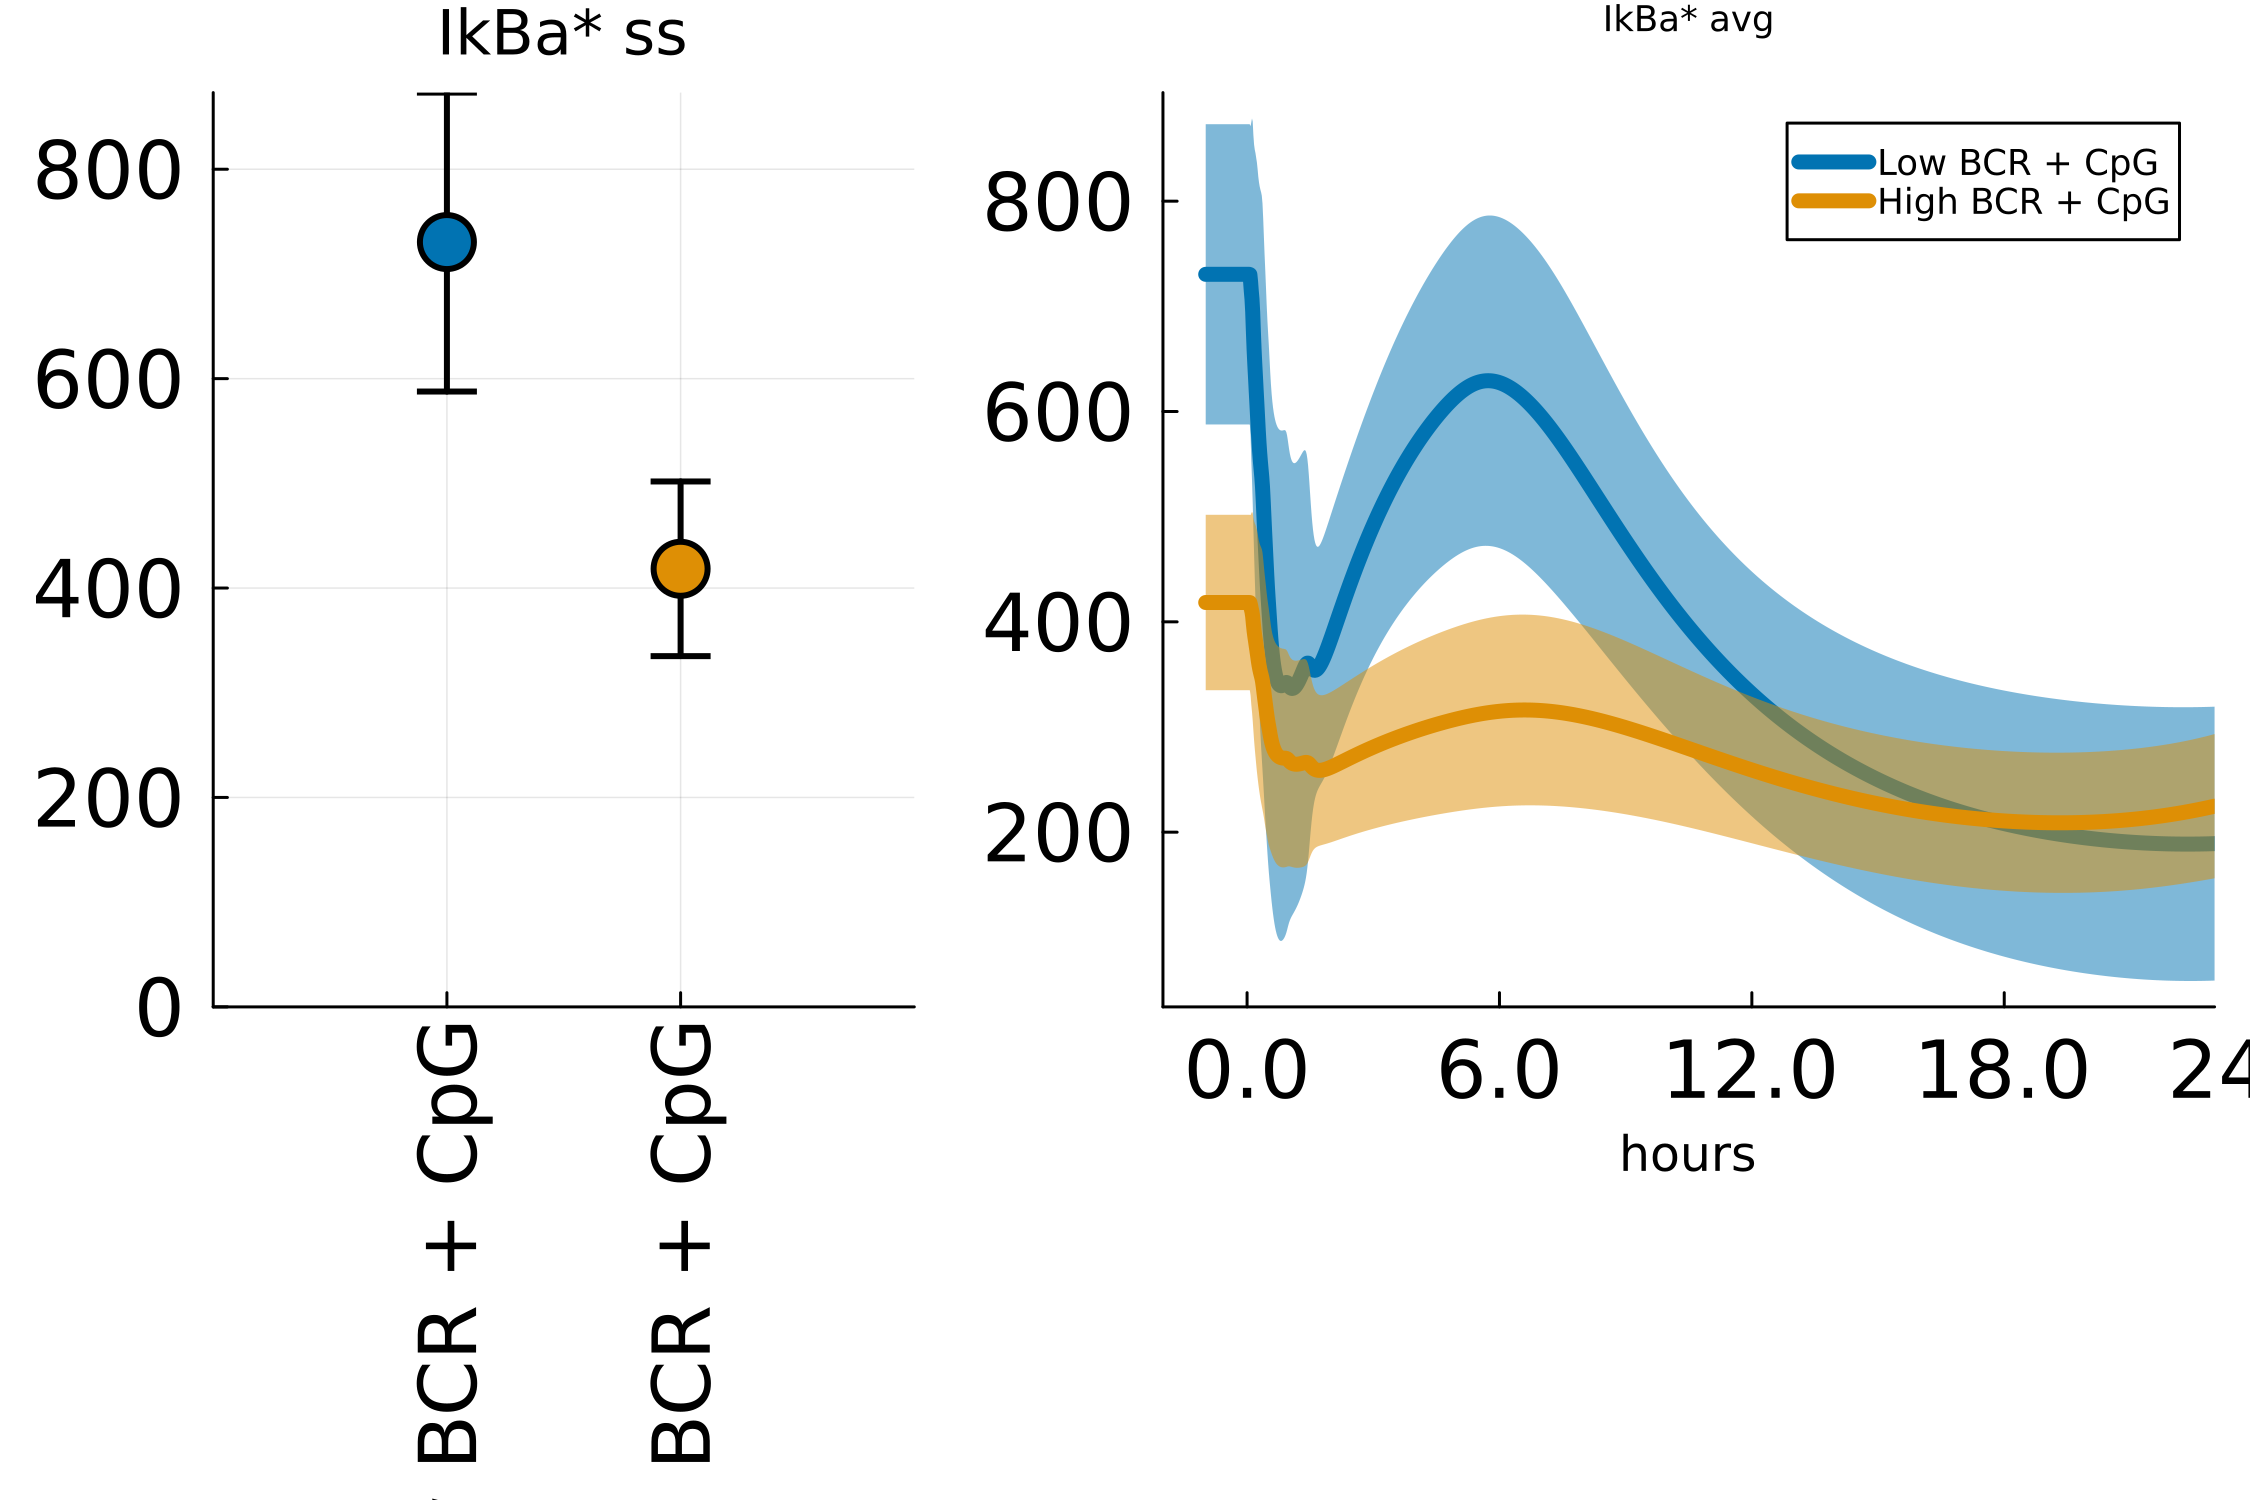

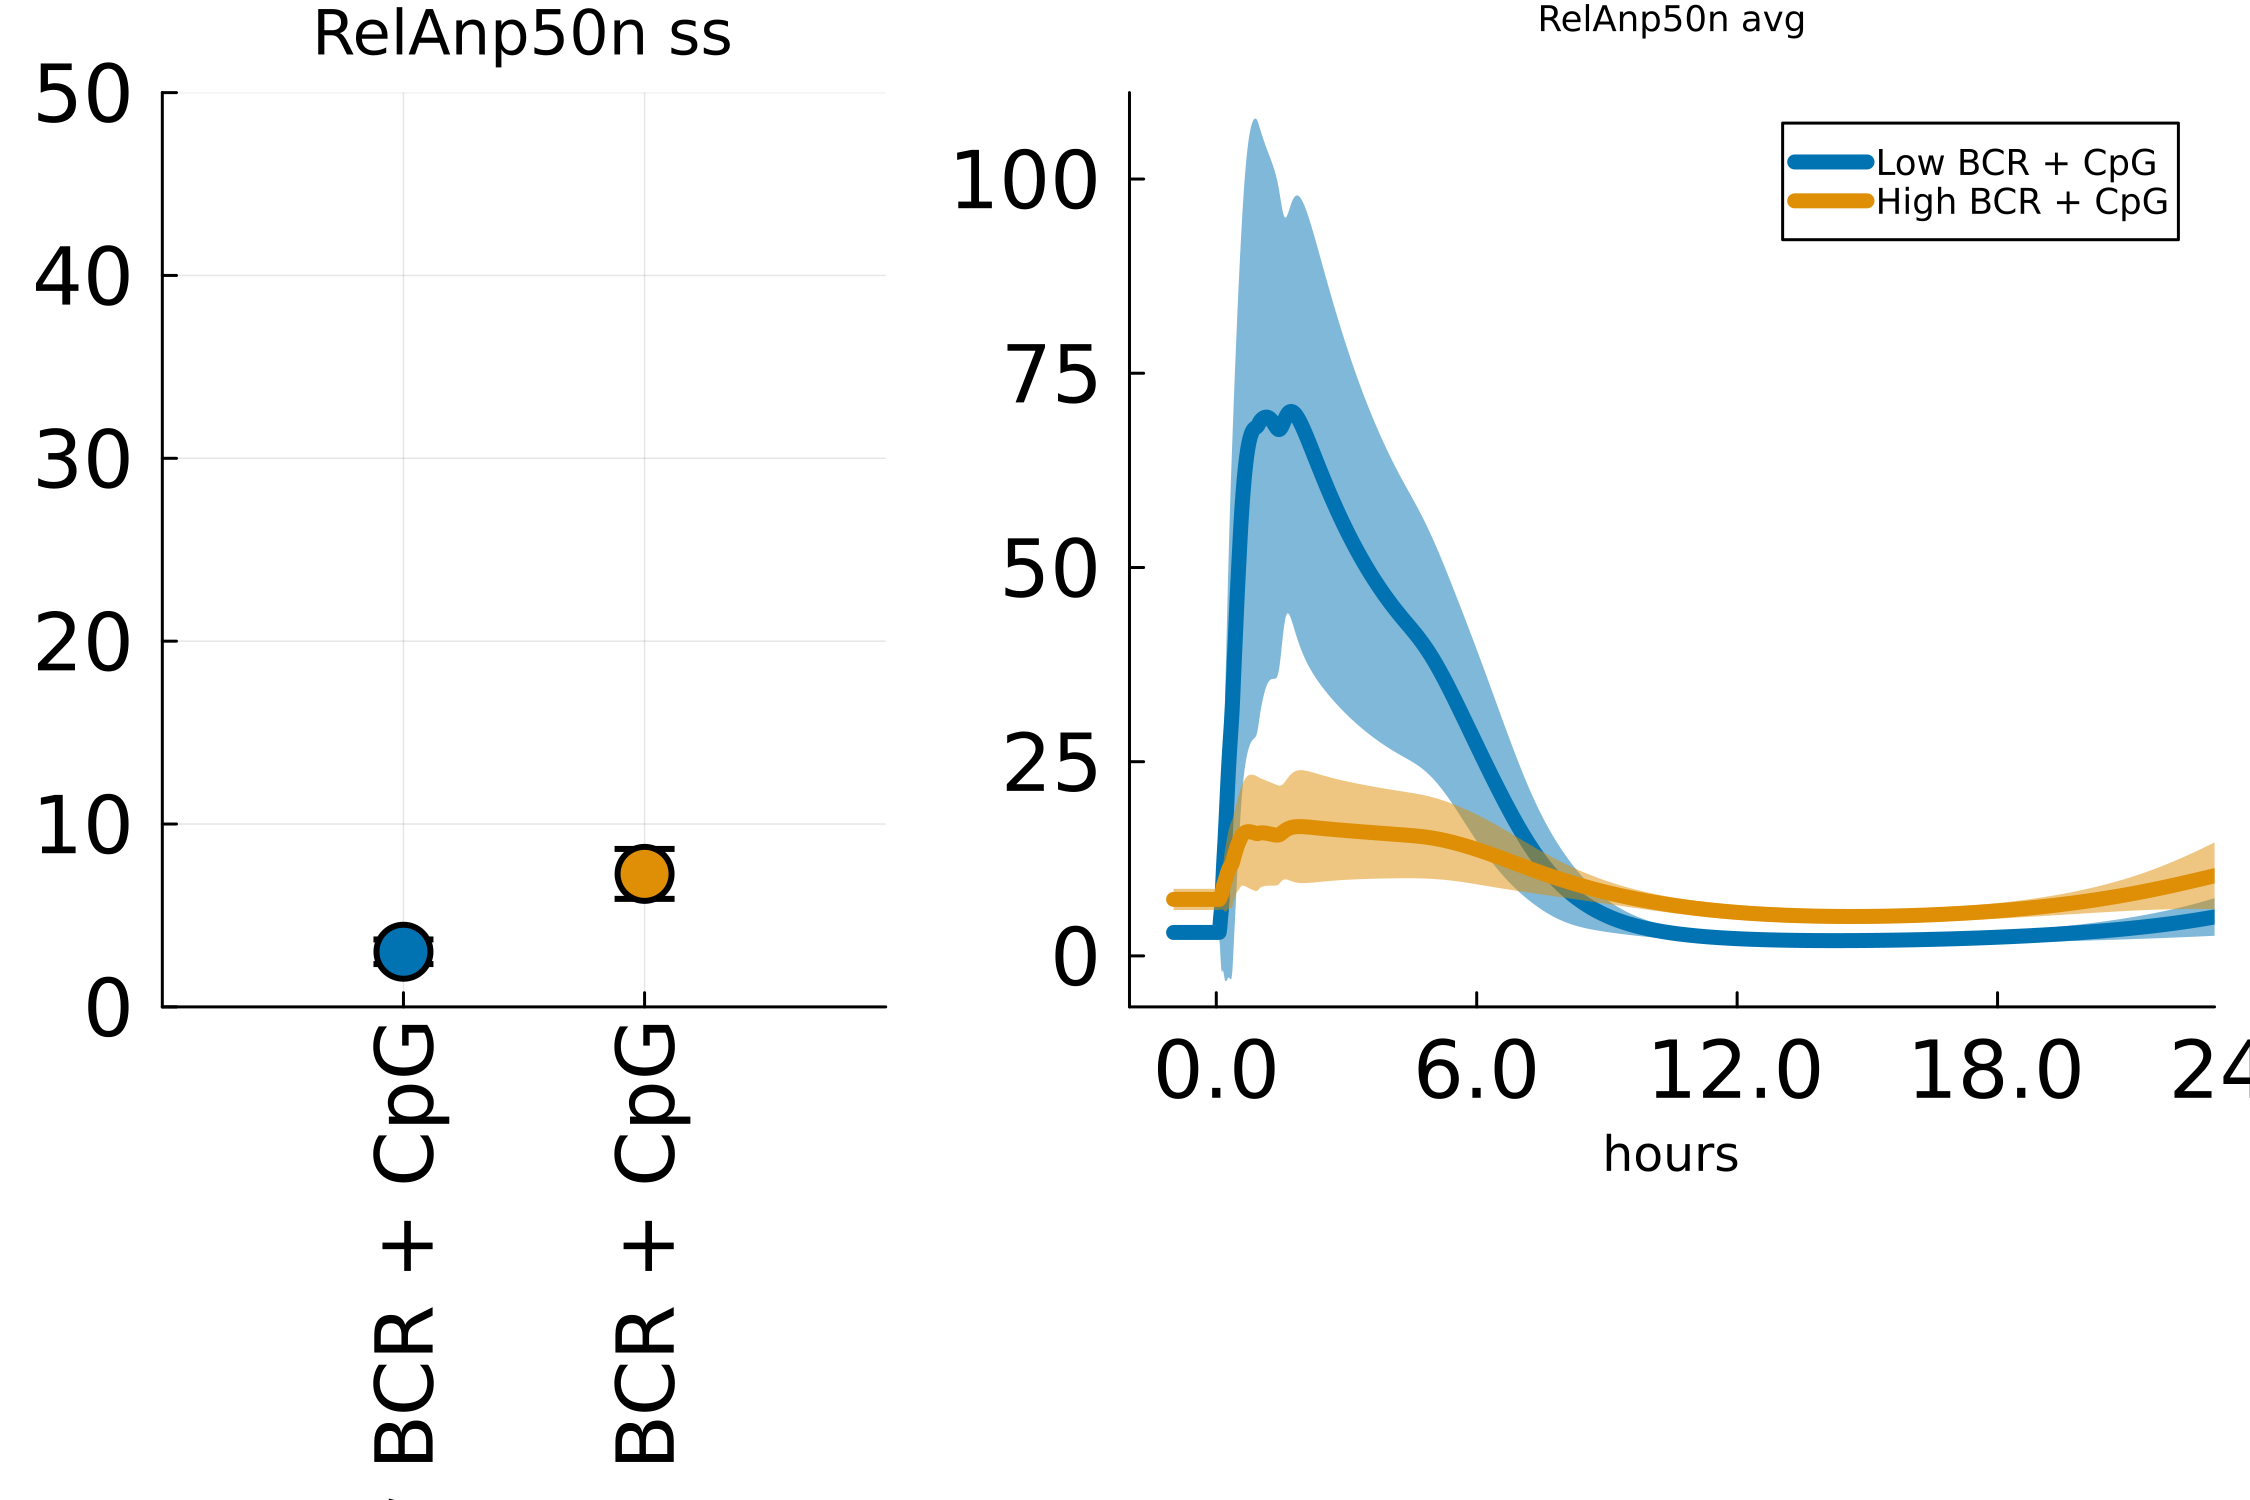

In [60]:
# Defines plotAllSpeciesNew(...): reads folder/sol_<condition>_cell_<i>.csv and plots mean ± SD across cells
include("plotAllSpeciesNew.jl")
hoursToPlot=24                               # x-axis range of the time-course panel: 0–7 h
colorArray=palette(:seaborn_colorblind)     # one colour per condition (same palette as before)
speciesToPlot=syms                          # would plot all 130 species... (immediately overridden below)
maxValOfYAxis=50                           # minimum upper y-limit for the steady-state dot plot
# Species to plot. A trailing "*" means "sum every species whose name contains this text and doesn't
# start with 't' (mRNA)", so "IkBa*" = total IκBα protein (free + NF-κB-bound, cytoplasm + nucleus).
# "RelAnp50n" = nuclear RelA:p50, the main NF-κB activity readout.
speciesToPlot=["IkBa*","RelAnp50n"]
#let't plot!
qualityScaling=0.5                          # scales figure size, marker size and stroke width
gr()                                        # use the GR plotting backend
# Last argument (60) = preStimTime: minutes of baseline padded before t = 0 using each cell's first value.
# For each species: left panel = mean ± SD at t = 0 (steady state) per condition,
# right panel = mean time course with SD ribbon. Also writes folder/allTCs_<species>_<condition>_cell.csv.
plotAllSpeciesNew(speciesToPlot,conditions,colorArray,first_cell,last_cell,folder,hoursToPlot,maxValOfYAxis,qualityScaling,60)
